In [1]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

import h5py
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")


In [2]:


def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [3]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/hresolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    #dos_normalized-=dos_normalized[0]
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720_le/%d/%s/out_dos.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500
subset_map={"H2O":"$H_2O$","SiO2":"$SiO_2$","Total":"Total"}
for pdos_file,(temperature,subset) in results_directory.items():
    print(pdos_file)
    h5file=h5py.File(pdos_file)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
    df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_list.append(df_tmp)
        
df_dos_mdanse=pd.concat(df_list,ignore_index=True)
df_dos_mdanse

../results/gromacs/pore/4nm/H2O/results_720_le/100/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/100/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/100/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/150/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/200/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/250/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720_le/300/Total/out_do

,dos H (nm2/ps),dos M (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Energy Transfer (meV),Normalized Count,Max Normalized Count,Temperature (K),Subset,dos Si (nm2/ps)
0,0.000014,0.000010,1.033359e-05,0.000014,0.062835,2.501685,9.999875e-01,0.041358,0.000074,0.003310,100,$H_2O$,NaN
1,0.000014,0.000011,1.044359e-05,0.000014,0.125670,2.486913,9.999500e-01,0.082716,0.000074,0.003343,100,$H_2O$,NaN
2,0.000014,0.000011,1.062712e-05,0.000014,0.188505,2.462486,9.998875e-01,0.124074,0.000076,0.003397,100,$H_2O$,NaN
3,0.000014,0.000011,1.088446e-05,0.000014,0.251340,2.428692,9.998000e-01,0.165432,0.000077,0.003474,100,$H_2O$,NaN
4,0.000015,0.000011,1.121602e-05,0.000015,0.314175,2.385922,9.996875e-01,0.206790,0.000080,0.003572,100,$H_2O$,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209974,0.000022,NaN,2.523867e-08,0.000021,628.035787,0.000000,3.716009e-17,413.373155,0.000033,0.001578,400,Total,6.103163e-08
209975,0.000022,NaN,2.524778e-08,0.000021,628.098622,0.000000,2.741944e-18,413.414513,0.000033,0.001578,400,Total,6.105807e-08
209976,0.000022,NaN,2.525467e-08,0.000021,628.161457,0.000000,4.071618e-17,413.455871,0.000033,0.001579,400,Total,6.107806e-08
209977,0.000022,NaN,2.525930e-08,0.000021,628.224292,0.000000,8.530829e-18,413.497229,0.000033,0.001579,400,Total,6.109147e-08


In [5]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720_le/%d/%s/dos.csv" % (temperature,subset)]=(temperature,subset)

df_list=list()
for pdos_file,(temperature,subset) in results_directory.items():
    df_tmp=pd.read_csv(pdos_file,names=['Wave number $(cm^{-1})',"dos","dos(solid)","dos(diff)"],skiprows=1)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset_map[subset]
    df_tmp['Energy Transfer (meV)']=df_tmp['Wave number $(cm^{-1})']*0.124
    dos=df_tmp["dos(solid)"].values
    energy=df_tmp["Energy Transfer (meV)"].values
    original_area = simpson(dos, energy)
    df_tmp["Normalized Count"] = apply_gaussian_broadening(df_tmp,metric="dos(solid)")
    df_tmp["Max Normalized Count"] = df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_list.append(df_tmp)

df_dos_gmx=pd.concat(df_list,ignore_index=True)
df_dos_gmx

,Wave number $(cm^{-1}),dos,dos(solid),dos(diff),Temperature (K),Subset,Energy Transfer (meV),Normalized Count,Max Normalized Count
0,0.00000,1.57570,0.000000,1.575700,100,$H_2O$,0.000000,0.000000,0.000000
1,1.33426,1.61096,0.035337,1.575630,100,$H_2O$,0.165448,0.000030,0.002287
2,2.66851,1.69155,0.116155,1.575400,100,$H_2O$,0.330895,0.000098,0.007518
3,4.00277,1.68574,0.110719,1.575020,100,$H_2O$,0.496343,0.000093,0.007166
4,5.33703,1.72219,0.147701,1.574490,100,$H_2O$,0.661792,0.000125,0.009560
...,...,...,...,...,...,...,...,...,...
52495,3328.97000,11.44560,11.391000,0.054585,400,Total,412.792280,0.001318,0.132783
52496,3330.30000,11.44590,11.391300,0.054541,400,Total,412.957200,0.001318,0.132786
52497,3331.64000,11.44590,11.391400,0.054498,400,Total,413.123360,0.001318,0.132788
52498,3332.97000,11.44580,11.391400,0.054454,400,Total,413.288280,0.001318,0.132788


,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.000147,2.054655,0.000074,1.00,0.000059,0.000063,0.000059,5.473765e-05,0.356514,0.334530,3.089565e-01,3.473644e-11,1.722343e-09,4.565176e-09,1.283153e-09,$H_2O$
1,100,0.000147,2.060672,0.000074,1.05,0.000059,0.000063,0.000059,5.385032e-05,0.359313,0.334508,3.061784e-01,3.838431e-11,1.761633e-09,4.318989e-09,1.036496e-09,$H_2O$
2,100,0.000147,2.067153,0.000074,1.10,0.000058,0.000065,0.000058,5.264235e-05,0.367611,0.332574,2.998143e-01,4.643199e-11,1.978135e-09,4.499086e-09,9.274407e-10,$H_2O$
3,100,0.000147,2.074115,0.000074,1.15,0.000056,0.000066,0.000058,5.145821e-05,0.376535,0.330597,2.928687e-01,5.771580e-11,2.288601e-09,4.841956e-09,8.621429e-10,$H_2O$
4,100,0.000147,2.089535,0.000074,1.20,0.000054,0.000068,0.000058,4.957847e-05,0.387620,0.328992,2.833885e-01,8.338464e-11,2.885365e-09,5.321528e-09,7.177624e-10,$H_2O$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,400,0.000337,1.450825,0.005681,1.80,0.005655,0.000297,0.000041,1.771137e-05,0.836089,0.114058,4.985249e-02,1.732006e-10,2.808148e-09,2.415661e-09,6.988151e-11,Total
437,400,0.000339,1.430860,0.005679,1.85,0.005662,0.000238,0.000118,5.600295e-13,0.668358,0.331642,1.575343e-09,8.032000e-11,1.245483e-09,1.024484e-09,2.707942e-11,Total
438,400,0.000342,1.410721,0.005677,1.90,0.005659,0.000249,0.000110,8.071497e-14,0.692615,0.307385,2.246310e-10,8.868600e-11,1.316542e-09,1.036524e-09,2.508341e-11,Total
439,400,0.000348,1.369937,0.005673,1.95,0.005653,0.000273,0.000094,2.031551e-07,0.742916,0.256532,5.521981e-04,1.085086e-10,1.480369e-09,1.070721e-09,2.184124e-11,Total


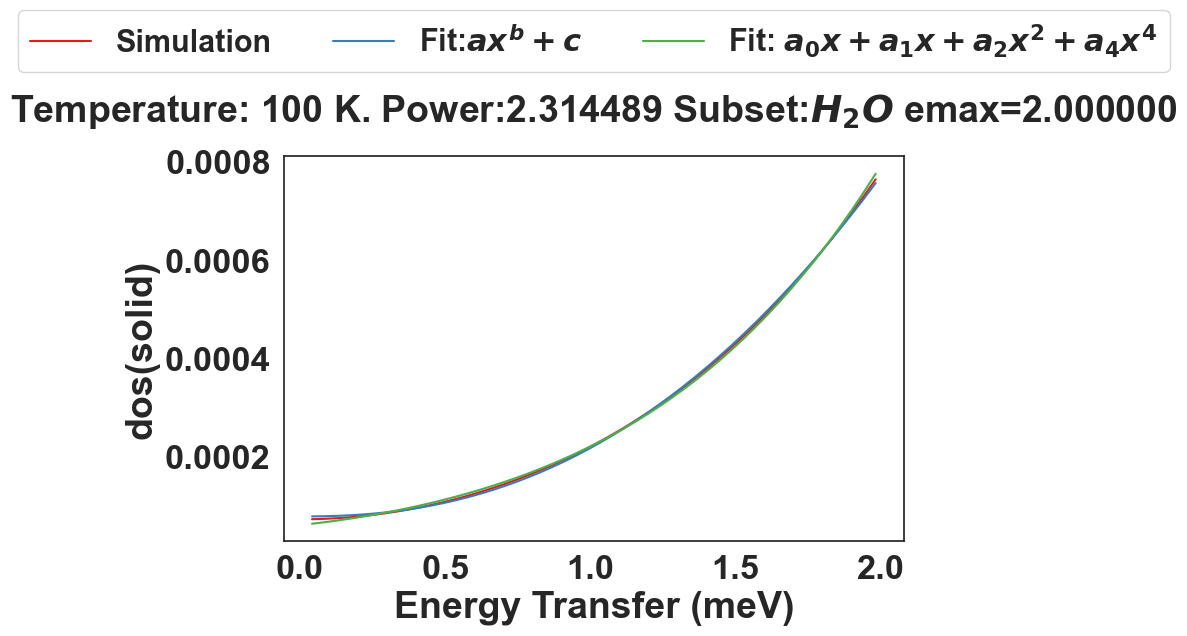

In [37]:
def power(x,a,b,c):
    return a*x**b+c

def taylor_series(x,a0,a1,a2,a4):
    return a0+a1*x+a2*x**2+a4*x**4

emax_l=1
emax_r=2
d_emax=0.05
df_data=df_dos_mdanse.copy()
df_list=list()
for i,subset in enumerate(df_data["Subset"].unique()):
    data_list=list()
    for j,temperature in enumerate(df_data["Temperature (K)"].unique()):
        for emax in np.arange(emax_l,emax_r+d_emax,d_emax):  
            df_tmp=df_data.query("0 <= `Energy Transfer (meV)` <= %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
            xdata=df_tmp["Energy Transfer (meV)"].values
            ydata=df_tmp["Normalized Count"].values
            popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
            popt_14, pcov_14 = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1],bounds=([-np.inf,0,0,0],[np.inf,np.inf,np.inf,np.inf]),method='trf')
            
            norm=np.sum(np.abs(popt_14[1:]))
            cv_14=np.diag(pcov_14)
            data_list.append({
                "Temperature (K)":temperature
                , "a(T)":popt[0]
                , "b(T)":popt[1]
                , "c(T)":popt[2] 
                ,"emax":emax
                ,"$a_0$":popt_14[0]
                ,"$a_1$":popt_14[1]
                ,"$a_2$":popt_14[2]
                #,"$a_3$":popt_14[3]
                ,"$a_4$":popt_14[3]
                ,"$n_1$":popt_14[1]/norm
                ,"$n_2$":popt_14[2]/norm
                #,"$n_3$":popt_14[3]/norm
                ,"$n_4$":popt_14[3]/norm
                ,"$\\Delta a_0$":cv_14[0]
                ,"$\\Delta a_1$":cv_14[1]
                ,"$\\Delta a_2$":cv_14[2]
                #,"$\\Delta a_3$":cv_14[3]
                ,"$\\Delta a_4$":cv_14[3]
                             })
        if i>0 or j>0:
            continue

        fig, ax = plt.subplots(figsize=(8,5))
        df_fit=pd.concat([
            pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)":ydata,"data":"Simulation"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": power(xdata, *popt),"data":"Fit:$ax^b+c$"})
            ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos(solid)": taylor_series(xdata, *popt_14),"data":"Fit: $a_0x+a_1x+a_2x^2+a_4x^4$"})
        ],ignore_index=True)
        sns.lineplot(data=df_fit
            , y='dos(solid)'
                 , x='Energy Transfer (meV)'
                 ,ax=ax
                ,hue='data'
                 ,palette='Set1'
                )
        ax.set_title("Temperature: %d K. Power:%f Subset:%s emax=%f"%(temperature,popt[1],subset,emax),pad=25)
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")


    df_tmp=pd.DataFrame(data_list)
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
    
df_power=pd.concat(df_list,ignore_index=True)
    
df_power

In [38]:
df_power["Subset"].unique() 

array(['$H_2O$', '$SiO_2$', 'Total'], dtype=object)

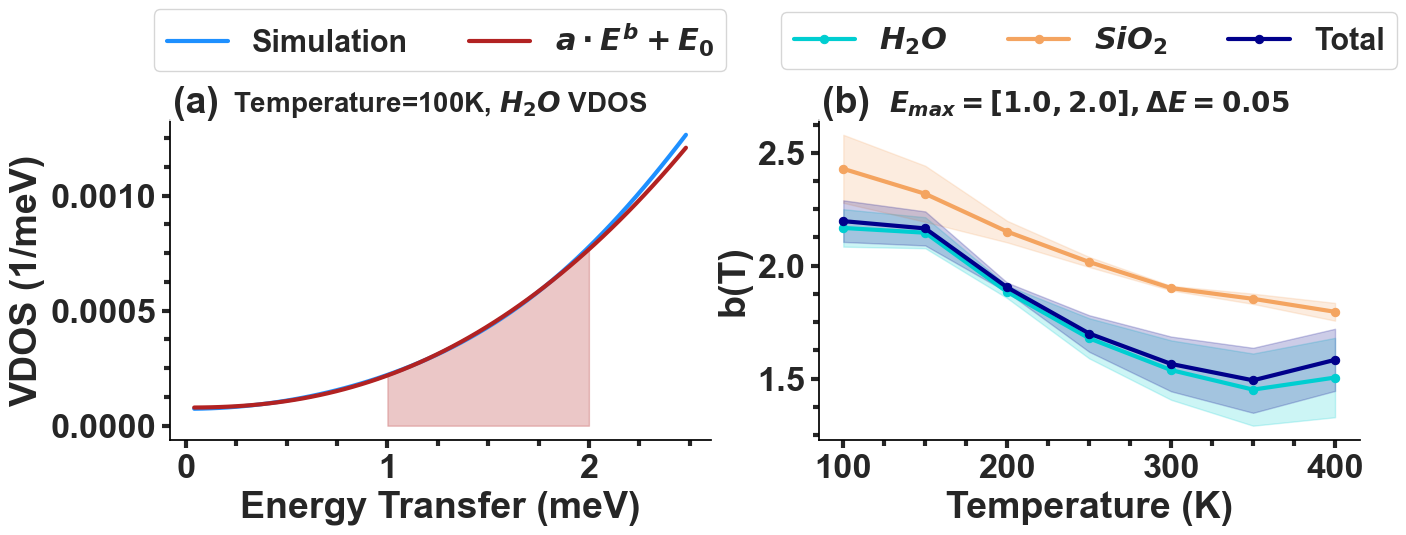

In [39]:
fig, axs = plt.subplots(ncols=2,figsize=(7*2,4))
labx=0.00625
laby=1.025
index=["(%s)"%x for x in list("abcdefghijkl")]

temperature=100
ax=axs[0]
subset="$H_2O$"
ax.text(labx, laby, index[0],weight='bold' ,transform=ax.transAxes)
df_tmp=df_data.query("`Temperature (K)`==%d and Subset == '%s' and `Energy Transfer (meV)` < %f"%(temperature,subset,emax_r+10*d_emax))
sns.lineplot(data=df_tmp
            ,y="Normalized Count"
            ,x="Energy Transfer (meV)"
            ,ax=ax
            ,lw=3
            ,label="Simulation" 
             ,color='dodgerblue'
       )
xdata=df_tmp["Energy Transfer (meV)"].values
ds=df_power.query("`Temperature (K)`==%d and Subset == '%s' and emax >= %f"%(temperature,subset,emax-d_emax))
a,b,c=ds[["a(T)","b(T)","c(T)"]].values[0]
df_fit=pd.DataFrame({"Energy Transfer (meV)":xdata,"Fitted VDOS (1/meV)": power(xdata,a,b,c),"data":"Fit:$ax^b+c$"})
sns.lineplot(data=df_fit
            ,y="Fitted VDOS (1/meV)"
            ,x="Energy Transfer (meV)"
            ,ax=ax
             ,lw=3
            ,label="$a\cdot E^b+E_0$" 
             ,color='firebrick'
       )


apply_ax_format(ax,xlabel="Energy Transfer (meV)",ylabel="VDOS (1/meV)")

legend_y=1.25
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")
ax.set_title("Temperature=%dK, %s VDOS"%(temperature,subset),fontsize=20)
ymax=df_fit["Fitted VDOS (1/meV)"].max()
#ax.vlines(x=emax_l,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')
#ax.vlines(x=3.5,ymin=0,ymax=ymax,colors='firebrick',linestyles='--')

xdata=np.linspace(emax_l,emax_r)
ax.fill_between(xdata, 0, power(xdata,a,b,c),color='firebrick', alpha=0.25)

ax=axs[1]
ax.text(labx, laby, index[1],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_power
            , y='b(T)'
                 , x='Temperature (K)'
                 ,ax=ax
                 ,marker='o'
#                 ,markerfacecolor="grey"
                 ,markeredgecolor=None
                ,hue='Subset'
             ,lw=3
             ,errorbar="sd"
                 ,palette=["darkturquoise","sandybrown","darkblue"]
                )


apply_ax_format(ax,legend=True,xlabel="Temperature (K)",ylabel="b(T)")
ax.set_title("$E_{max}=[%.1f,%.1f],\\Delta E=%.2f$"%(df_power["emax"].min(),df_power["emax"].max(),df_power["emax"].diff().max()),fontsize=20)
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=3,fontsize=22,title_fontsize=22,title="")

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.
                   )

plt.savefig("../figures/fig11.pdf", pad_inches=0.2,bbox_inches="tight")

In [21]:
df_taylor_fit=pd.melt(df_power[["Temperature (K)","Subset","$n_1$","$n_2$","$n_4$"]],id_vars=["Temperature (K)","Subset"],value_vars=["$n_1$","$n_2$","$n_4$"])
df_taylor_fit

,Temperature (K),Subset,variable,value
0,100,$H_2O$,$n_1$,0.421457
1,100,$H_2O$,$n_1$,0.424125
2,100,$H_2O$,$n_1$,0.252278
3,100,$H_2O$,$n_1$,0.266816
4,100,$H_2O$,$n_1$,0.295179
...,...,...,...,...
1948,400,Total,$n_4$,0.000495
1949,400,Total,$n_4$,0.000130
1950,400,Total,$n_4$,0.000302
1951,400,Total,$n_4$,0.000299


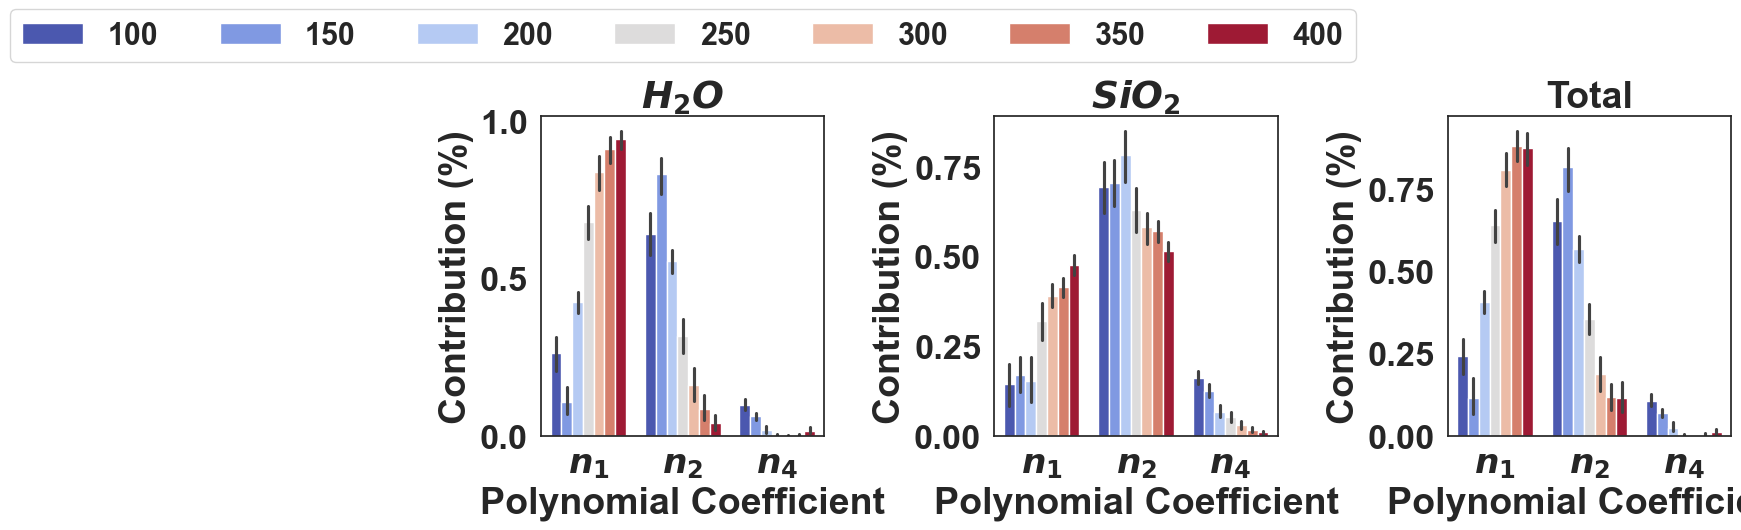

In [22]:
fig, axs = plt.subplots(ncols=3,figsize=(7*2,4))

for i, subset in enumerate(df_taylor_fit["Subset"].unique()):
    ax=axs[i]
    sns.barplot(data=df_taylor_fit.query("Subset == '%s'"%subset)
                , y='value'
                     , x='variable'
                     ,hue='Temperature (K)'
                ,palette="coolwarm"
                ,ax=ax
                ,legend=i==0
                    )
    
    if i==0:
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,legend_y),ncol=7,fontsize=22,title_fontsize=22,title="",)
    ax.set_xlabel("Polynomial Coefficient")
    ax.set_ylabel("Contribution (%)")
    ax.set_title(subset)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.6, 
                    hspace=0.
                   )


In [23]:
def format_table(x):
    coeff,mettric=x.name
    result=x.copy()
    if coeff in ["a(T)","c(T)"]:
        result*=1e4
    if mettric == "mean":        
        result=result.map(lambda x : "%.1f"%x)
    else:
        result=result.map(lambda x : "%.2f"%x)
    return result

df_summary=df_power.groupby(["Temperature (K)","Subset"])[["a(T)","b(T)","c(T)"]].aggregate(["mean","std"])
df_summary_formatted=df_summary.apply(format_table).rename(columns={"mean":"$\mu$","std":"$\sigma$"})
print(df_summary_formatted.to_latex())

\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{2}{r}{a(T)} & \multicolumn{2}{r}{b(T)} & \multicolumn{2}{r}{c(T)} \\
 &  & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ & $\mu$ & $\sigma$ \\
Temperature (K) & Subset &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{100} & $H_2O$ & 1.4 & 0.06 & 2.3 & 0.09 & 0.8 & 0.03 \\
 & $SiO_2$ & 0.9 & 0.05 & 2.7 & 0.12 & 0.4 & 0.02 \\
 & Total & 1.3 & 0.06 & 2.4 & 0.09 & 0.7 & 0.03 \\
\cline{1-8}
\multirow[t]{3}{*}{150} & $H_2O$ & 1.9 & 0.04 & 2.2 & 0.05 & 1.4 & 0.02 \\
 & $SiO_2$ & 1.2 & 0.05 & 2.5 & 0.09 & 0.6 & 0.02 \\
 & Total & 1.8 & 0.04 & 2.3 & 0.05 & 1.3 & 0.02 \\
\cline{1-8}
\multirow[t]{3}{*}{200} & $H_2O$ & 4.4 & 0.20 & 1.8 & 0.07 & 4.9 & 0.11 \\
 & $SiO_2$ & 1.8 & 0.03 & 2.2 & 0.03 & 1.1 & 0.01 \\
 & Total & 4.0 & 0.16 & 1.8 & 0.06 & 4.4 & 0.09 \\
\cline{1-8}
\multirow[t]{3}{*}{250} & $H_2O$ & 7.7 & 0.62 & 1.5 & 0.13 & 15.4 & 0.39 \\
 & $SiO_2$ & 2.6 & 0.03 & 2.0 & 0.02 & 2.4 & 0.02 \\
 & Total & 7.0 & 0.50 & 1.5 & 0.12 & 13.5 & 0.32 \\
\cli

In [30]:
np.sum(df_dos_mdanse["Energy Transfer (meV)"].unique() < 1)

np.int64(24)

In [24]:
import ipywidgets as widgets

def power(x,a,b,c):
    return a*x**b+c


def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(20,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(20,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(power, xdata, ydata,p0=[1,3,0],method='lm')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a(T)":popt[0]
            , "b(T)":popt[1]
            , "c(T)":popt[2] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": power(xdata, *popt),"data":"Fit:$ax^b+c$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ax.set_title("Temperature: %d K. Power:%.1f Subset:%s emax=%.1f"%(temperature,popt[1],subset,emax),pad=25)
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.4),ncol=4,fontsize=22,title_fontsize=22,title="")

    parameters_str="\n".join(["%s=%.2e ± %.2e"%("abc"[i],x,dx) for i, (x,dx) in enumerate(zip(popt,cov_diag))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
 

d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=1,max=3,value=1.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=1…

In [25]:
def taylor_series(x,a0,a1,a2,a3,a4):
    return a0+a1*x+a2*x**2+a3*x**3+a4*x**4

def fit_dos(df_mdanse,df_gmx,dos,emax,temperature,subset):
    if dos == "mdanse":
        df_tmp2=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_mdanse.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
    else:
        df_tmp2=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax*2,temperature,subset))
        df_tmp=df_gmx.query("0.1 <= `Energy Transfer (meV)` < %f and `Temperature (K)` == %d and Subset == '%s'"%(emax,temperature,subset))
        
       
    xdata_ex=df_tmp2["Energy Transfer (meV)"].values
    ydata_ex=df_tmp2["Normalized Count"].values
    xdata=df_tmp["Energy Transfer (meV)"].values
    ydata=df_tmp["Normalized Count"].values
    popt, pcov = curve_fit(taylor_series, xdata, ydata,p0=[1,1,1,1,1],bounds=([-np.inf,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]),method='trf')
    cond_number=np.linalg.cond(pcov)
    cov_diag=np.diag(pcov)
    data_list.append({
            "Temperature (K)":temperature
            , "a1(T)":popt[0]
            , "a2(T)":popt[1]
            , "b(T)":popt[2]
            , "c(T)":popt[3] 
            ,"emax":emax
                         })
    
    fig, ax = plt.subplots(figsize=(8,5))
    df_fit=pd.concat([
        pd.DataFrame({"Energy Transfer (meV)":xdata_ex,"dos":ydata_ex,"data":"Simulation"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos":ydata,"data":"Fitted"})
        ,pd.DataFrame({"Energy Transfer (meV)":xdata,"dos": taylor_series(xdata, *popt),"data":"Fit: $a0+a_1x+a_2x^2+a_3x^3+a_4x^4$"})

    ],ignore_index=True)
    ax=sns.lineplot(data=df_fit
        , y='dos'
             , x='Energy Transfer (meV)'
            ,hue='data'
             ,palette='Set1'
             ,lw=3
            ,ax=ax
            )
#    ax.loglog()
    ds_tmp=pd.Series({i+1:abs(x) for i,x in enumerate(popt[1:])})
    ax.set_title("Temperature: %d K. Power:%d Subset:%s emax=%.1f"%(temperature,ds_tmp.idxmax(),subset,emax),pad=25)

    parameters_str="\n".join(["$a_%d$=%.2e (%.1f %%)"%(i,x,dx) for i, (x,dx) in enumerate(zip(popt,100*np.abs(popt)/np.sum(np.abs(popt))))])
    ax.text(1, 0.5,parameters_str,ha="left",va="center",weight='bold' ,transform=ax.transAxes)
    
    sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.3),ncol=4,fontsize=22,title_fontsize=22,title="")



d=widgets.interact(fit_dos
                 ,df_mdanse=widgets.fixed(df_dos_mdanse)
                 ,df_gmx=widgets.fixed(df_dos_gmx)
                 ,dos=["gmx","mdanse"]
                 ,emax=widgets.FloatSlider(min=0.5,max=5,value=2.5)
                 ,temperature=df_dos_mdanse["Temperature (K)"].unique()
                 ,subset=df_dos_mdanse["Subset"].unique()
                 )

interactive(children=(Dropdown(description='dos', options=('gmx', 'mdanse'), value='gmx'), FloatSlider(value=2…

In [14]:
df_power.query("`Temperature (K)`==100 and Subset == '$H_2O$'")

,Temperature (K),a(T),b(T),c(T),emax,$a_0$,$a_1$,$a_2$,$a_4$,$n_1$,$n_2$,$n_4$,$\Delta a_0$,$\Delta a_1$,$\Delta a_2$,$\Delta a_4$,Subset
0,100,0.000297,2.724305,0.000030,1.50,-0.000003,1.182388e-04,1.125286e-04,1.008622e-04,3.565387e-01,3.393202e-01,3.041410e-01,1.693018e-08,4.581919e-07,6.260697e-07,3.782444e-08,$H_2O$
1,100,0.000297,2.724305,0.000030,1.55,-0.000003,1.182388e-04,1.125286e-04,1.008622e-04,3.565387e-01,3.393202e-01,3.041410e-01,1.693018e-08,4.581919e-07,6.260697e-07,3.782444e-08,$H_2O$
2,100,0.000297,2.724305,0.000030,1.60,-0.000003,1.182388e-04,1.125286e-04,1.008622e-04,3.565387e-01,3.393202e-01,3.041410e-01,1.693018e-08,4.581919e-07,6.260697e-07,3.782444e-08,$H_2O$
3,100,0.000297,2.724305,0.000030,1.65,-0.000003,1.182388e-04,1.125286e-04,1.008622e-04,3.565387e-01,3.393202e-01,3.041410e-01,1.693018e-08,4.581919e-07,6.260697e-07,3.782444e-08,$H_2O$
4,100,0.000338,2.171895,0.000011,1.70,-0.000002,9.133835e-11,3.590800e-04,3.574582e-06,2.518604e-07,9.901430e-01,9.856709e-03,1.565611e-08,3.395303e-07,3.733015e-07,1.484843e-08,$H_2O$
5,100,0.000338,2.171895,0.000011,1.75,-0.000002,9.133835e-11,3.590800e-04,3.574582e-06,2.518604e-07,9.901430e-01,9.856709e-03,1.565611e-08,3.395303e-07,3.733015e-07,1.484843e-08,$H_2O$
6,100,0.000338,2.171895,0.000011,1.80,-0.000002,9.133835e-11,3.590800e-04,3.574582e-06,2.518604e-07,9.901430e-01,9.856709e-03,1.565611e-08,3.395303e-07,3.733015e-07,1.484843e-08,$H_2O$
7,100,0.000383,1.750492,-0.000011,1.85,-0.000015,1.263793e-04,2.461773e-04,6.062821e-06,3.337898e-01,6.501972e-01,1.601297e-02,1.655804e-08,2.942582e-07,2.659938e-07,7.248915e-09,$H_2O$
8,100,0.000383,1.750492,-0.000011,1.90,-0.000015,1.263793e-04,2.461773e-04,6.062821e-06,3.337898e-01,6.501972e-01,1.601297e-02,1.655804e-08,2.942582e-07,2.659938e-07,7.248915e-09,$H_2O$
9,100,0.000383,1.750492,-0.000011,1.95,-0.000015,1.263793e-04,2.461773e-04,6.062821e-06,3.337898e-01,6.501972e-01,1.601297e-02,1.655804e-08,2.942582e-07,2.659938e-07,7.248915e-09,$H_2O$
